# World Bank WDI — Exploratory Data Analysis
**Author : Shankha Roy** 
**Version: 1.0.0 — Created: 2026-04-11**

---

This notebook performs comprehensive EDA on the World Bank WDI panel dataset produced by the `wdi_etl` pipeline.

## Contents

1. [Setup & Data Loading](#1-setup)  
2. [Panel Overview](#2-overview)  
3. [Summary Statistics](#3-summary)  
4. [Missing-Value Analysis](#4-missingness)  
5. [Coverage by Country](#5-coverage-country)  
6. [Coverage by Year](#6-coverage-year)  
7. [Indicator Correlation Matrix](#7-correlation)  
8. [Distribution Analysis](#8-distribution)  
9. [Top & Bottom Countries](#9-top-bottom)  
10. [Time-Series Visualisation](#10-timeseries)  

---

### Importing necessary libraries

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Setup & Data Loading
# ─────────────────────────────────────────────────────────────────────────────

# Import system-specific parameters and functions
import sys

# Import warnings module to control warning messages
import warnings

# Import matplotlib for plotting graphs and visualizations
import matplotlib.pyplot as plt

# Import NumPy for numerical operations and handling arrays
import numpy as np

# Import pandas for data manipulation and analysis (DataFrames, Series)
import pandas as pd

# Import seaborn for advanced statistical data visualization (built on matplotlib)
import seaborn as sns

# Import Path from pathlib for handling file paths in an object-oriented way
from pathlib import Path

# Add parent directory to path so we can import wdi_etl as a package
sys.path.insert(0, str(Path("../").resolve()))

# Removes the limit for the number of displayed columns in Pandas DataFrames
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows in Pandas DataFrames
pd.set_option("display.max_rows", 200)


# Import various EDA (Exploratory Data Analysis) utility functions 
# and constants from the wdi_etl package
# Add local package paths so the notebook can import wdi_etl from the repo
repo_root = Path.cwd()
package_paths = [
    repo_root / "wdi_etl",
    repo_root / "src" / "wdi_etl",
    repo_root.parent / "wdi_etl",
    repo_root.parent / "src" / "wdi_etl",
]
for pkg_path in package_paths:
    if pkg_path.exists():
        import_path = pkg_path.parent
        if str(import_path) not in sys.path:
            sys.path.insert(0, str(import_path.resolve()))
        break

from wdi_etl.eda import (
    load_panel,                 # Function to load panel dataset
    summary_stats,              # Generate summary statistics of the dataset
    missingness_report,         # Report missing values in the dataset
    missingness_heatmap_data,   # Prepare data for missingness heatmap visualization
    coverage_by_country,        # Analyze data coverage across countries
    coverage_by_year,           # Analyze data coverage across years
    indicator_correlation,      # Compute correlations between indicators
    distribution_by_indicator,  # Analyze distributions of indicators
    top_bottom,                 # Get top and bottom values for indicators
    time_series_data,           # Prepare time series data for analysis/plotting
    INDICATOR_LABELS,           # Dictionary mapping indicator codes to readable labels
)

# -----------------------------
# Plot styling configuration
# -----------------------------

# Suppress warning messages for cleaner output
warnings.filterwarnings("ignore")

# Set seaborn theme for better-looking plots
sns.set_theme(style="whitegrid", font_scale=1.1)

# Configure default figure size (width, height in inches)
plt.rcParams["figure.figsize"] = (12, 6)

# Set resolution (dots per inch) for figures
plt.rcParams["figure.dpi"] = 100

# Set default font size for plot titles
plt.rcParams["axes.titlesize"] = 14

# Set default font size for axis labels
plt.rcParams["axes.labelsize"] = 12

# Print confirmation message indicating environment setup is complete
print("Environment ready.")

Environment ready.


### Loading the dataset

In [2]:
# Load the panel — automatically detects CSV or Parquet
PANEL_PATH = Path("../data/output/wdi_panel.csv")
# load the data in dataframe for processing
df = load_panel(PANEL_PATH)
print(f"Panel shape : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
df.head(10)

Panel shape : (11817, 5)
Columns     : ['country_iso3', 'country_name', 'year', 'value', 'indicator_code']


,country_iso3,country_name,year,value,indicator_code
0,AFE,Africa Eastern and Southern,2023,27.8,IT.NET.USER.ZS
1,AFE,Africa Eastern and Southern,2022,26.8,IT.NET.USER.ZS
2,AFE,Africa Eastern and Southern,2021,25.0,IT.NET.USER.ZS
3,AFE,Africa Eastern and Southern,2020,23.5,IT.NET.USER.ZS
4,AFE,Africa Eastern and Southern,2019,21.6,IT.NET.USER.ZS
5,AFE,Africa Eastern and Southern,2018,19.6,IT.NET.USER.ZS
6,AFE,Africa Eastern and Southern,2017,17.3,IT.NET.USER.ZS
7,AFE,Africa Eastern and Southern,2016,16.3,IT.NET.USER.ZS
8,AFE,Africa Eastern and Southern,2015,14.3,IT.NET.USER.ZS
9,AFE,Africa Eastern and Southern,2014,12.1,IT.NET.USER.ZS


### Data Overview

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Panel Overview
# ─────────────────────────────────────────────────────────────────────────────

n_countries   = df["country_iso3"].nunique()
n_years       = df["year"].nunique()
n_indicators  = df["indicator_code"].nunique()
n_observations= len(df)

print(f"Countries    : {n_countries}")
print(f"Years        : {sorted(df['year'].unique())}")
print(f"Year range   : {df['year'].min()} – {df['year'].max()}")
print(f"Indicators   : {n_indicators}")
print(f"Total rows   : {n_observations:,}")
print(f"Missing vals : {df['value'].isna().sum():,}")

# dtypes
df.dtypes

Countries    : 255
Years        : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Year range   : 2014 – 2023
Indicators   : 5
Total rows   : 11,817
Missing vals : 0


country_iso3       object
country_name       object
year                int64
value             float64
indicator_code     object
dtype: object

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Summary Statistics
# ─────────────────────────────────────────────────────────────────────────────

stats = summary_stats(df)
stats

,n_obs,mean,std,min,q25,median,q75,max,null
indicator_code,,,,,,,,,
IT.NET.USER.ZS,2153,57.38,28.36,0.99,31.50,63.22,81.71,100.00,397
NY.GDP.PCAP.CD,2481,17716.81,26664.21,232.94,2322.89,6665.74,21912.15,256799.79,69
NY.GNP.PCAP.CD,2387,15200.77,20346.01,240.00,2220.00,6199.06,19080.00,134500.00,163
SL.TLF.CACT.FE.ZS,2246,50.26,14.94,4.75,44.02,52.15,59.50,83.41,304
SP.URB.TOTL.IN.ZS,2550,60.45,22.61,13.13,42.48,61.00,78.75,100.00,0


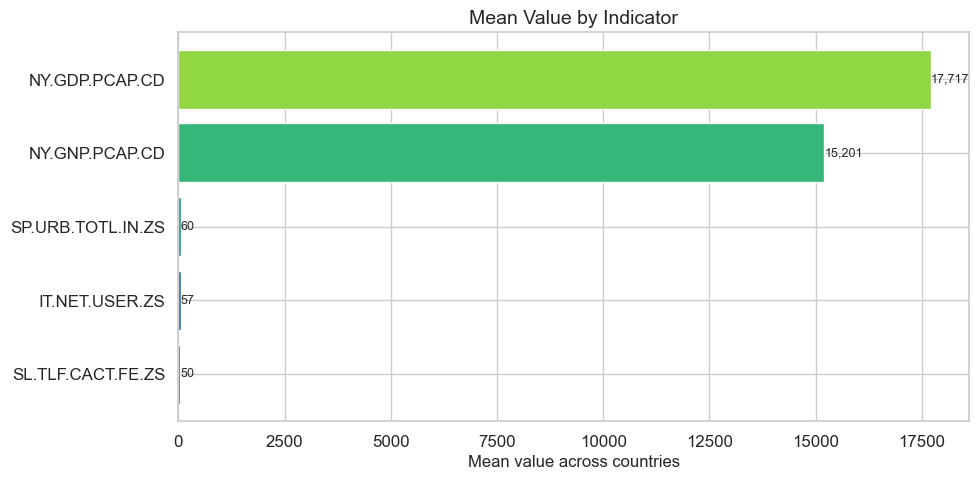

In [5]:
# Bar chart — mean value per indicator
fig, ax = plt.subplots(figsize=(10, 5))
means = stats["mean"].sort_values(ascending=True)
colors = sns.color_palette("viridis", len(means))
bars = ax.barh(means.index, means.values, color=colors)
ax.set_xlabel("Mean value across countries")
ax.set_title("Mean Value by Indicator")
for bar, val in zip(bars, means.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Missing-Value Analysis
# ─────────────────────────────────────────────────────────────────────────────

miss = missingness_report(df)
miss

,total_cells,non_null,null_count,missing_ratio
indicator_code,,,,
IT.NET.USER.ZS,2550,2153,397,0.1557
SL.TLF.CACT.FE.ZS,2550,2246,304,0.1192
NY.GNP.PCAP.CD,2550,2387,163,0.0639
NY.GDP.PCAP.CD,2550,2481,69,0.0271
SP.URB.TOTL.IN.ZS,2550,2550,0,0.0000


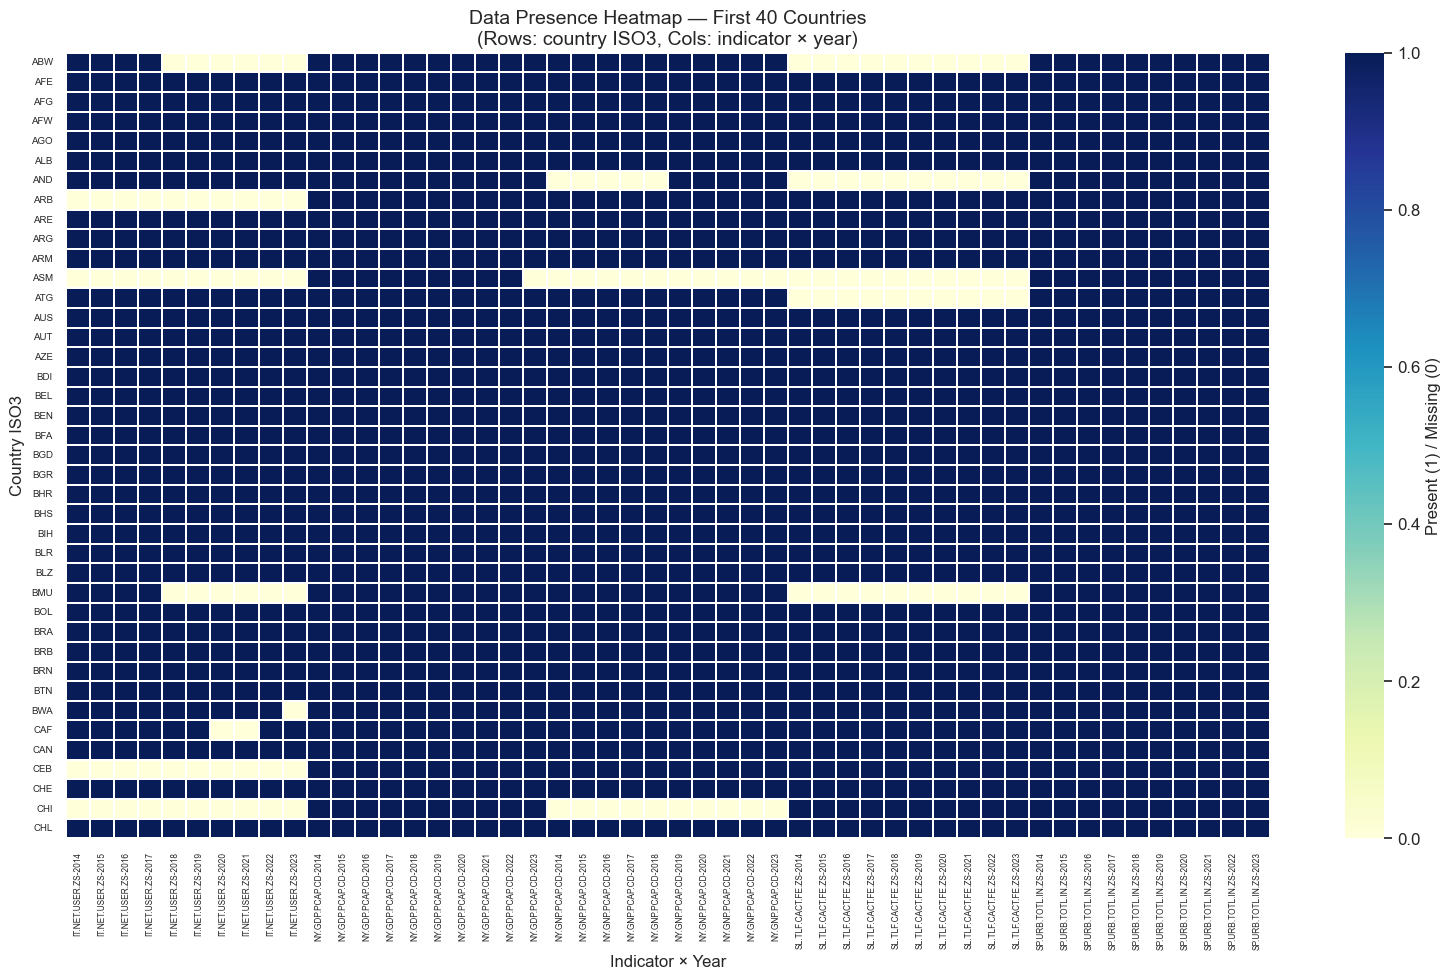

In [7]:
# Heatmap: non-null presence per indicator × year
heatmap_df = missingness_heatmap_data(df)

# Select a subset of countries for readability in the notebook
SAMPLE_COUNTRIES = 40
heatmap_sample = heatmap_df.head(SAMPLE_COUNTRIES)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    heatmap_sample,
    cmap="YlGnBu",
    cbar_kws={"label": "Present (1) / Missing (0)"},
    linewidths=0.1,
    linecolor="white",
    ax=ax,
)
ax.set_title(
    f"Data Presence Heatmap — First {SAMPLE_COUNTRIES} Countries\n"
    "(Rows: country ISO3, Cols: indicator × year)"
)
ax.set_xlabel("Indicator × Year")
ax.set_ylabel("Country ISO3")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Coverage by Country
# ─────────────────────────────────────────────────────────────────────────────

country_cov = coverage_by_country(df)
print(f"Well-covered countries (>= 5 obs per indicator): "
      f"{country_cov['is_well_covered'].sum()} / {len(country_cov)}")

country_cov.head(20)

Well-covered countries (>= 5 obs per indicator): 255 / 255


,country_iso3,country_name,n_indicators_with_data,n_years_with_data,n_total_obs,is_well_covered
0,LBR,Liberia,5,10,50,True
1,LVA,Latvia,5,10,50,True
2,MAR,Morocco,5,10,50,True
3,MDA,Moldova,5,10,50,True
4,MDG,Madagascar,5,10,50,True
5,MDV,Maldives,5,10,50,True
6,MEA,"Middle East, North Africa, Afghanistan & Pakistan",5,10,50,True
7,MEX,Mexico,5,10,50,True
8,MKD,North Macedonia,5,10,50,True
9,MLI,Mali,5,10,50,True


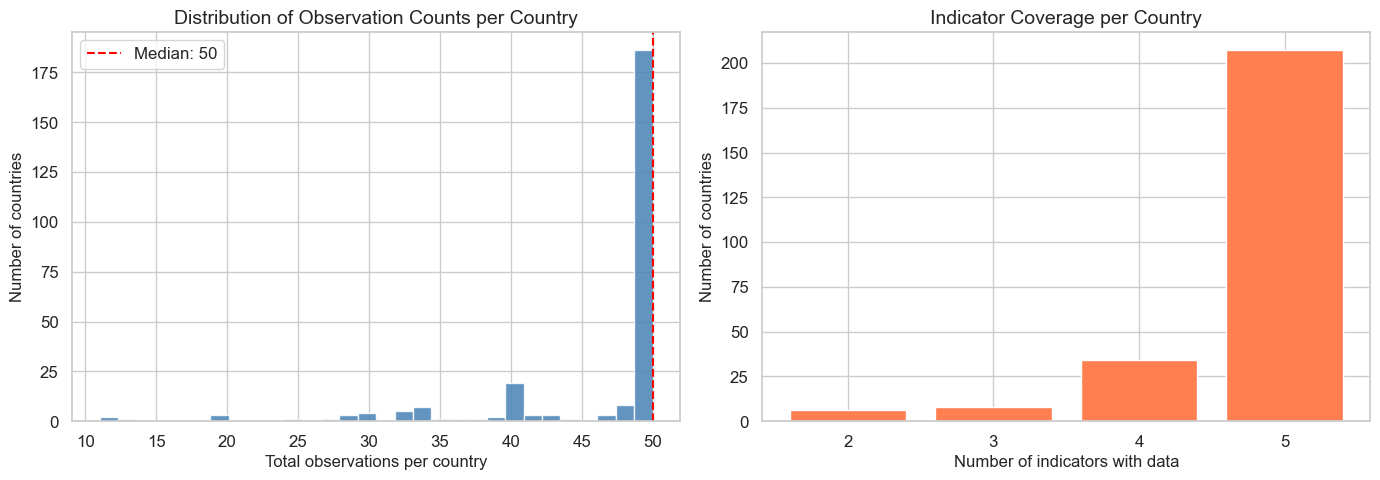

In [9]:
# Distribution of observation counts across countries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of total observations per country
axes[0].hist(country_cov["n_total_obs"], bins=30, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[0].axvline(country_cov["n_total_obs"].median(), color="red",
                linestyle="--", label=f"Median: {country_cov['n_total_obs'].median():.0f}")
axes[0].set_xlabel("Total observations per country")
axes[0].set_ylabel("Number of countries")
axes[0].set_title("Distribution of Observation Counts per Country")
axes[0].legend()

# Right: bar — indicators covered per country
ind_per_country = country_cov["n_indicators_with_data"].value_counts().sort_index()
axes[1].bar(ind_per_country.index.astype(str), ind_per_country.values,
           color="coral", edgecolor="white")
axes[1].set_xlabel("Number of indicators with data")
axes[1].set_ylabel("Number of countries")
axes[1].set_title("Indicator Coverage per Country")

plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. Coverage by Year
# ─────────────────────────────────────────────────────────────────────────────

year_cov = coverage_by_year(df)
year_cov

indicator_code,IT.NET.USER.ZS,NY.GDP.PCAP.CD,NY.GNP.PCAP.CD,SL.TLF.CACT.FE.ZS,SP.URB.TOTL.IN.ZS,total_indicators_reported
year,,,,,,
2014,226,251,238,225,255,5
2015,226,250,239,225,255,5
2016,228,249,238,225,255,5
2017,225,249,239,225,255,5
2018,207,249,239,225,255,5
2019,214,249,240,225,255,5
2020,209,248,239,225,255,5
2021,205,248,239,225,255,5
2022,207,247,239,224,255,5


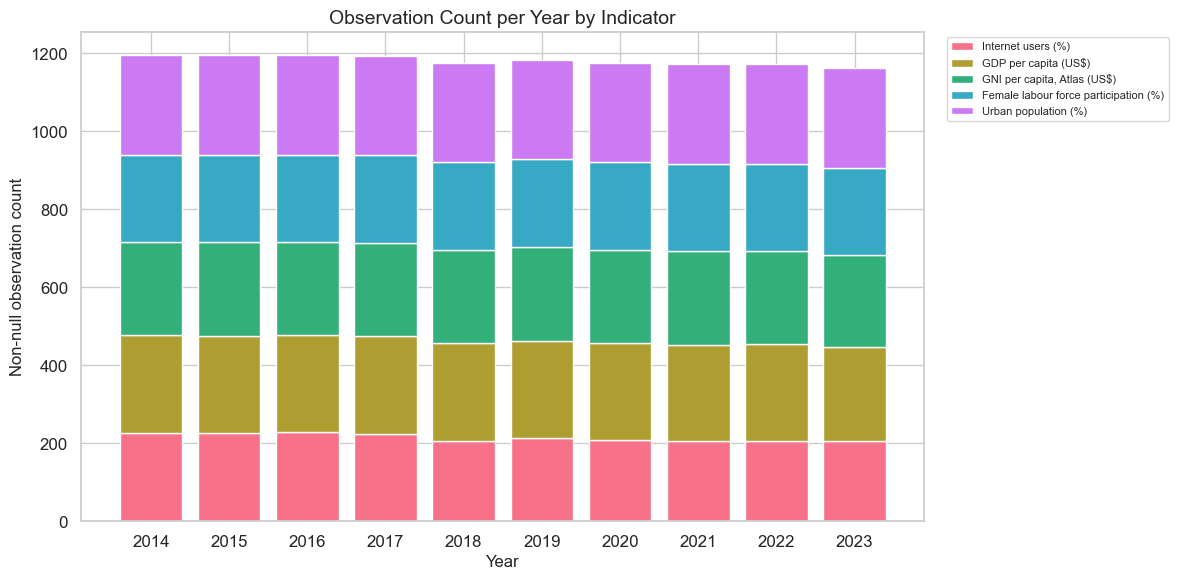

In [11]:
# Stacked bar — observation count per year, split by indicator
fig, ax = plt.subplots(figsize=(12, 6))

indicator_codes = [c for c in year_cov.columns
                  if c != "total_indicators_reported"]
bottom = np.zeros(len(year_cov))

palette = sns.color_palette("husl", len(indicator_codes))
for i, code in enumerate(indicator_codes):
    vals = year_cov[code].values
    ax.bar(year_cov.index.astype(str), vals, bottom=bottom,
           label=INDICATOR_LABELS.get(code, code), color=palette[i])
    bottom += vals

ax.set_xlabel("Year")
ax.set_ylabel("Non-null observation count")
ax.set_title("Observation Count per Year by Indicator")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Indicator Correlation Matrix
# ─────────────────────────────────────────────────────────────────────────────

corr = indicator_correlation(df)
corr

indicator_code,IT.NET.USER.ZS,NY.GDP.PCAP.CD,NY.GNP.PCAP.CD,SL.TLF.CACT.FE.ZS,SP.URB.TOTL.IN.ZS
indicator_code,,,,,
IT.NET.USER.ZS,1.0000,0.6205,0.6980,-0.0040,0.7175
NY.GDP.PCAP.CD,0.6205,1.0000,0.9880,0.1930,0.4443
NY.GNP.PCAP.CD,0.6980,0.9880,1.0000,0.1969,0.5794
SL.TLF.CACT.FE.ZS,-0.0040,0.1930,0.1969,1.0000,-0.0711
SP.URB.TOTL.IN.ZS,0.7175,0.4443,0.5794,-0.0711,1.0000


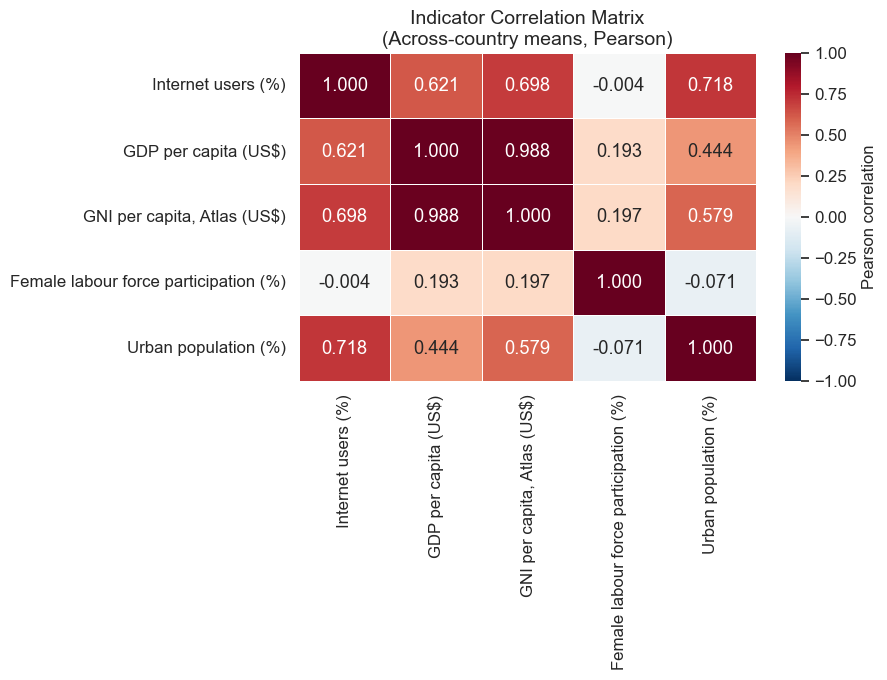

In [13]:
# Correlation heatmap
# Replace full indicator codes with short labels for readability
corr_labels = corr.copy()
corr_labels.index = [INDICATOR_LABELS.get(c, c) for c in corr_labels.index]
corr_labels.columns = [INDICATOR_LABELS.get(c, c) for c in corr_labels.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_labels, dtype=bool), k=1)
sns.heatmap(
    corr_labels,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Indicator Correlation Matrix\n(Across-country means, Pearson)")
plt.tight_layout()
plt.show()

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. Distribution Analysis
# ─────────────────────────────────────────────────────────────────────────────

dist = distribution_by_indicator(df)
dist

,n,mean,std,cv,min,q25,median,q75,max,iqr,skewness,kurtosis
indicator_code,,,,,,,,,,,,
NY.GDP.PCAP.CD,2481,17716.81,26664.21,1.5050,232.94,2322.89,6665.74,21912.15,256799.79,19589.26,3.2746,15.4984
NY.GNP.PCAP.CD,2387,15200.77,20346.01,1.3385,240.00,2220.00,6199.06,19080.00,134500.00,16860.00,2.0606,4.3648
SP.URB.TOTL.IN.ZS,2550,60.45,22.61,0.3741,13.13,42.48,61.00,78.75,100.00,36.27,-0.0564,-0.9386
IT.NET.USER.ZS,2153,57.38,28.36,0.4942,0.99,31.50,63.22,81.71,100.00,50.20,-0.3222,-1.1797
SL.TLF.CACT.FE.ZS,2246,50.26,14.94,0.2973,4.75,44.02,52.15,59.50,83.41,15.48,-0.6583,0.4589


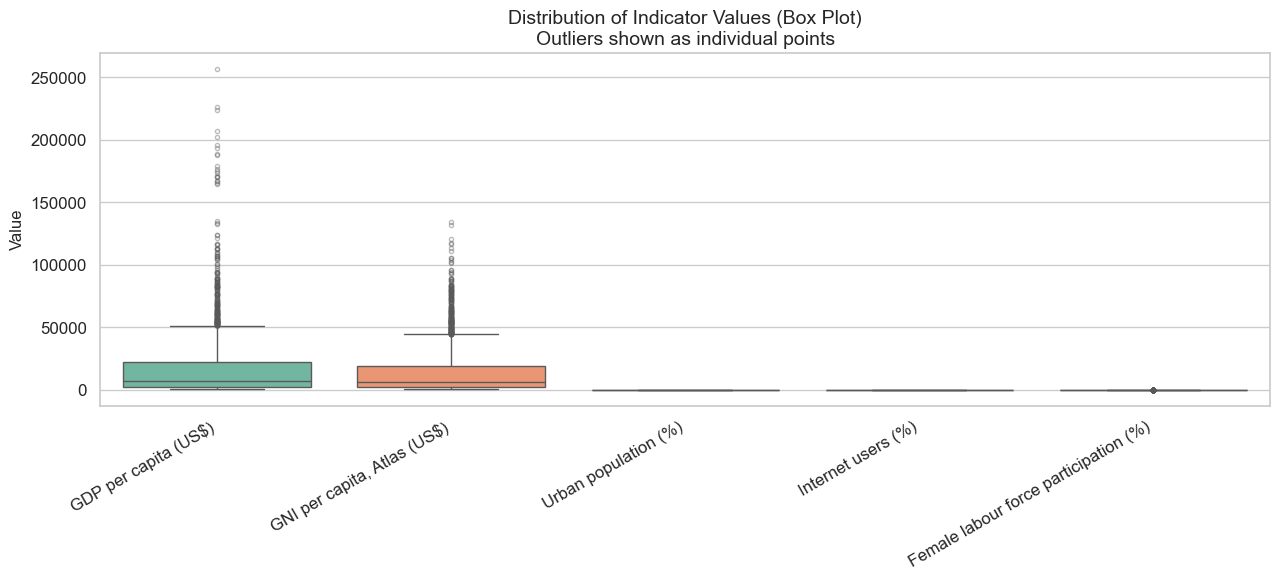

In [15]:
# Box plots per indicator — reveals outliers and skew
fig, ax = plt.subplots(figsize=(13, 6))

order = dist.index.tolist()
sns.boxplot(
    data=df,
    x="indicator_code",
    y="value",
    order=order,
    palette="Set2",
    showfliers=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    ax=ax,
)
ax.set_xticklabels([INDICATOR_LABELS.get(c, c) for c in order], rotation=30,
                   ha="right")
ax.set_xlabel("")
ax.set_ylabel("Value")
ax.set_title("Distribution of Indicator Values (Box Plot)\nOutliers shown as individual points")
plt.tight_layout()
plt.show()

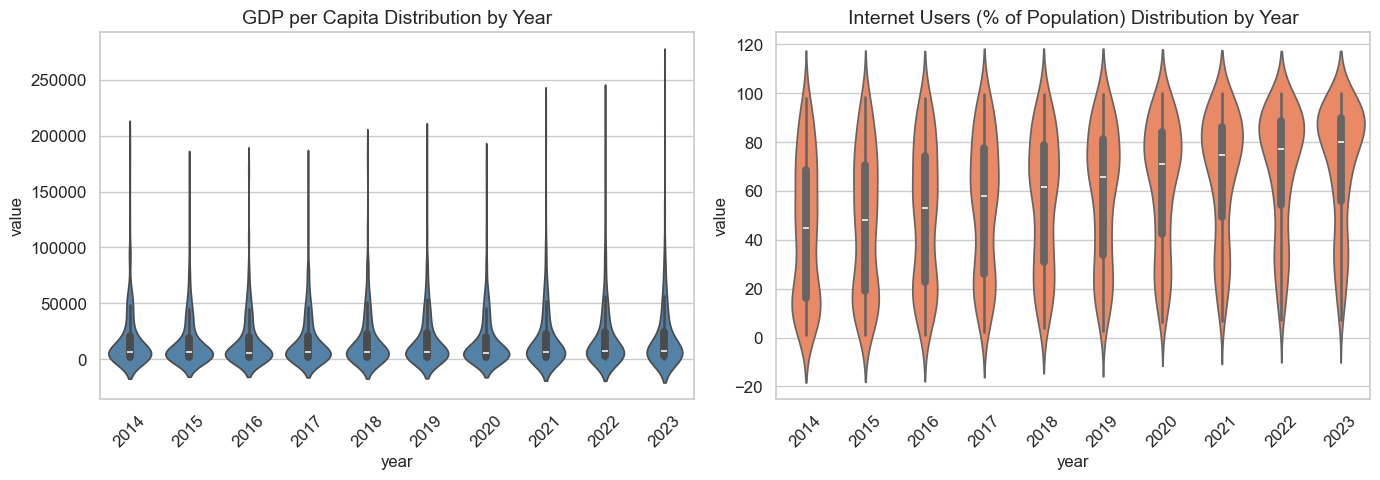

In [16]:
# Violin plots — show full distribution shape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: GDP per capita violin
gdp_df = df[df["indicator_code"] == "NY.GDP.PCAP.CD"].copy()
sns.violinplot(data=gdp_df, x="year", y="value", color="steelblue", ax=axes[0])
axes[0].set_title("GDP per Capita Distribution by Year")
axes[0].tick_params(axis="x", rotation=45)

# Right: Internet users violin
net_df = df[df["indicator_code"] == "IT.NET.USER.ZS"].copy()
sns.violinplot(data=net_df, x="year", y="value", color="coral", ax=axes[1])
axes[1].set_title("Internet Users (% of Population) Distribution by Year")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

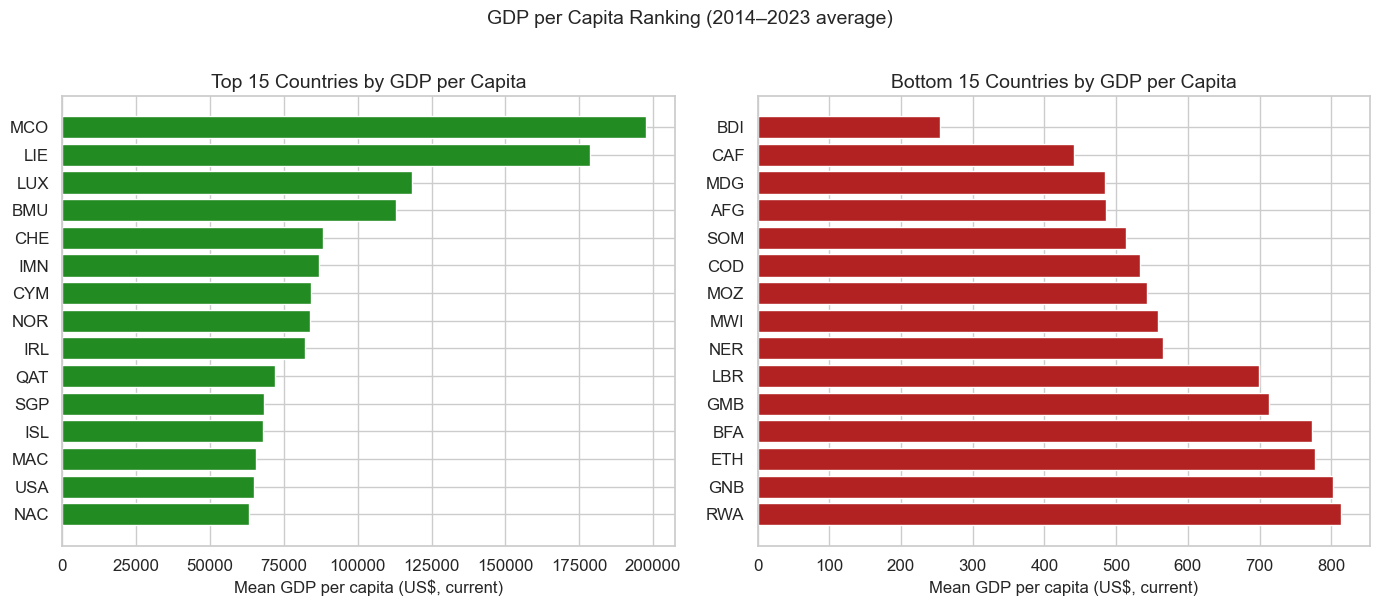


Top 15:


,country_iso3,country_name,mean_value,n_years,first_year,last_year
0,MCO,Monaco,197601.094306,10,2014,2023
1,LIE,Liechtenstein,178519.302589,10,2014,2023
2,LUX,Luxembourg,118463.275244,10,2014,2023
3,BMU,Bermuda,112986.659502,10,2014,2023
4,CHE,Switzerland,88085.880851,10,2014,2023
5,IMN,Isle of Man,86756.627516,9,2014,2022
6,CYM,Cayman Islands,84316.325337,10,2014,2023
7,NOR,Norway,83687.894121,10,2014,2023
8,IRL,Ireland,82269.453959,10,2014,2023
9,QAT,Qatar,72119.467814,10,2014,2023



Bottom 15:


,country_iso3,country_name,mean_value,n_years,first_year,last_year
0,BDI,Burundi,253.835050,10,2014,2023
1,CAF,Central African Republic,441.862694,10,2014,2023
2,MDG,Madagascar,484.359262,10,2014,2023
3,AFG,Afghanistan,486.441871,10,2014,2023
4,SOM,"Somalia, Fed. Rep.",513.358055,10,2014,2023
5,COD,Democratic Republic of the Congo,532.811329,10,2014,2023
6,MOZ,Mozambique,542.932823,10,2014,2023
7,MWI,Malawi,558.692518,10,2014,2023
8,NER,Niger,565.205858,10,2014,2023
9,LBR,Liberia,699.211966,10,2014,2023


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. Top & Bottom Countries
# ─────────────────────────────────────────────────────────────────────────────

# GDP per capita ranking
gdp_ranking = top_bottom(df, "NY.GDP.PCAP.CD", n=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15
top_df = gdp_ranking["top"].head(15)
axes[0].barh(top_df["country_iso3"][::-1], top_df["mean_value"][::-1],
             color="forestgreen", edgecolor="white")
axes[0].set_xlabel("Mean GDP per capita (US$, current)")
axes[0].set_title("Top 15 Countries by GDP per Capita")

# Bottom 15
bottom_df = gdp_ranking["bottom"].head(15)
axes[1].barh(bottom_df["country_iso3"][::-1], bottom_df["mean_value"][::-1],
             color="firebrick", edgecolor="white")
axes[1].set_xlabel("Mean GDP per capita (US$, current)")
axes[1].set_title("Bottom 15 Countries by GDP per Capita")

plt.suptitle("GDP per Capita Ranking (2014–2023 average)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nTop 15:")
display(gdp_ranking["top"])
print("\nBottom 15:")
display(gdp_ranking["bottom"])

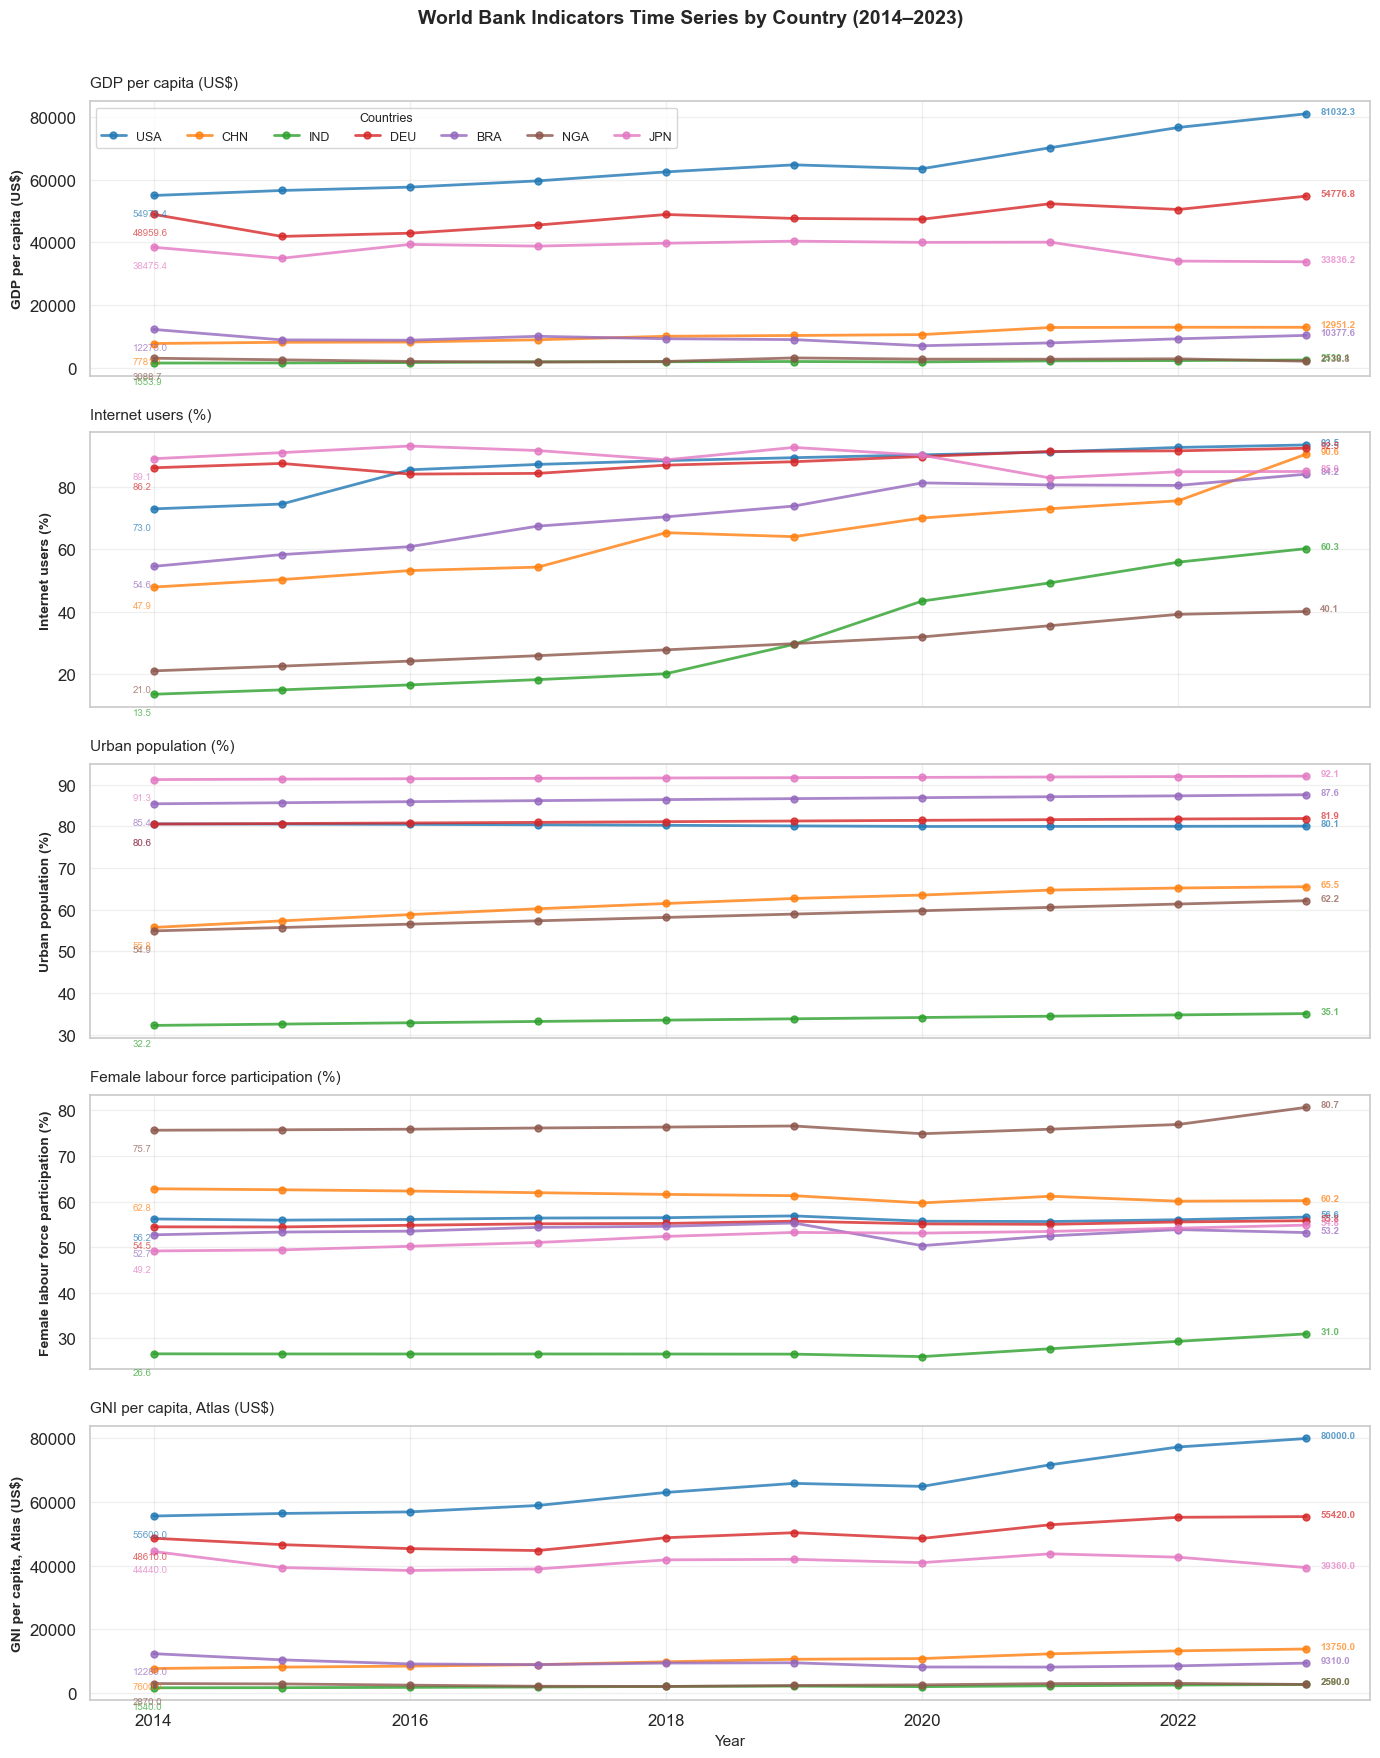

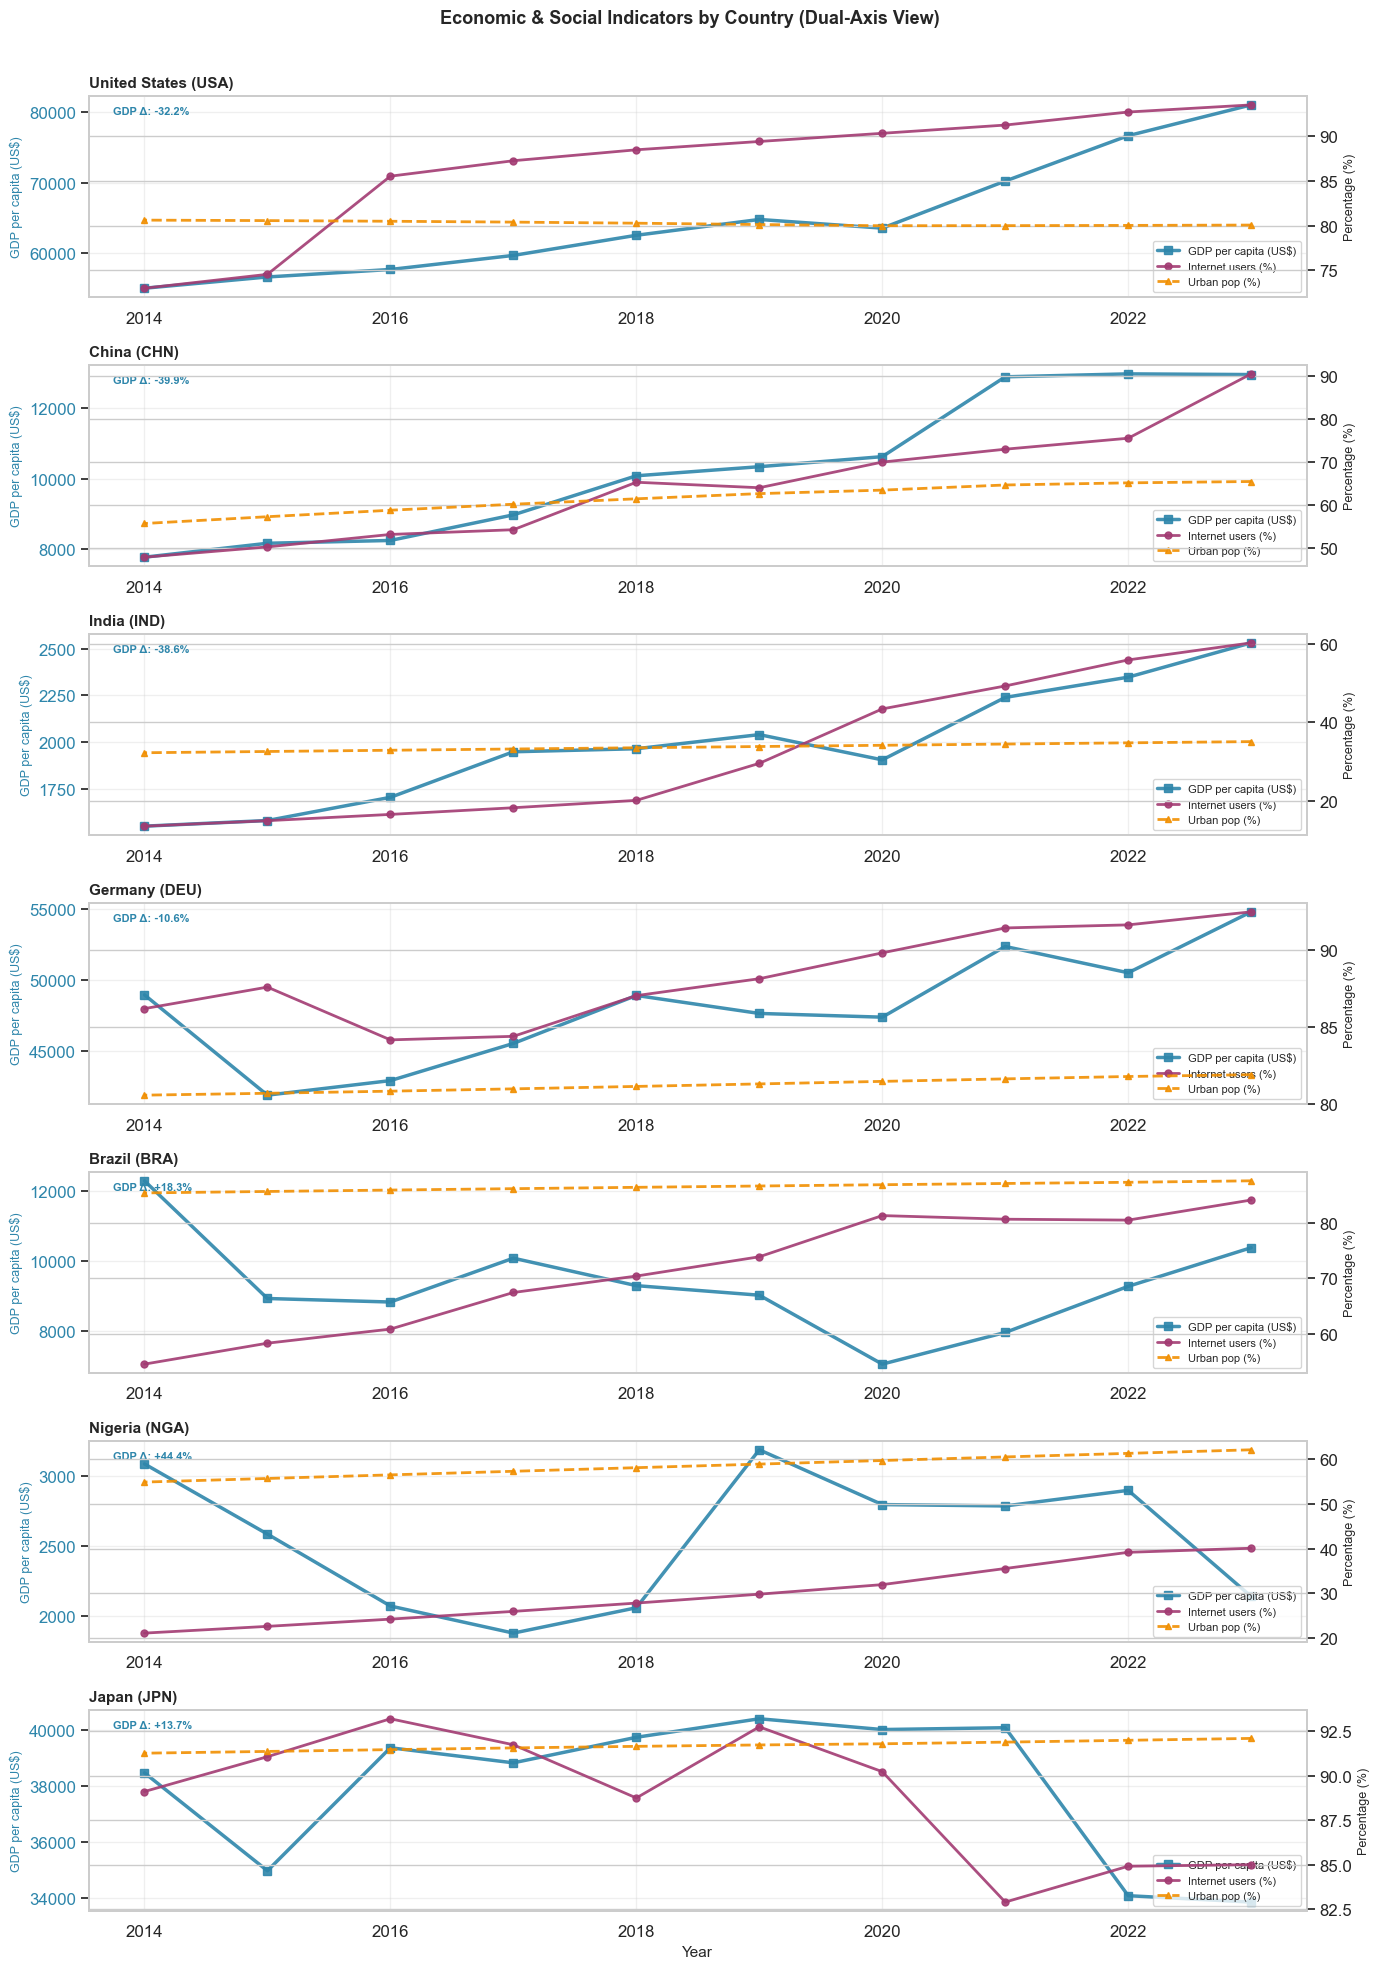

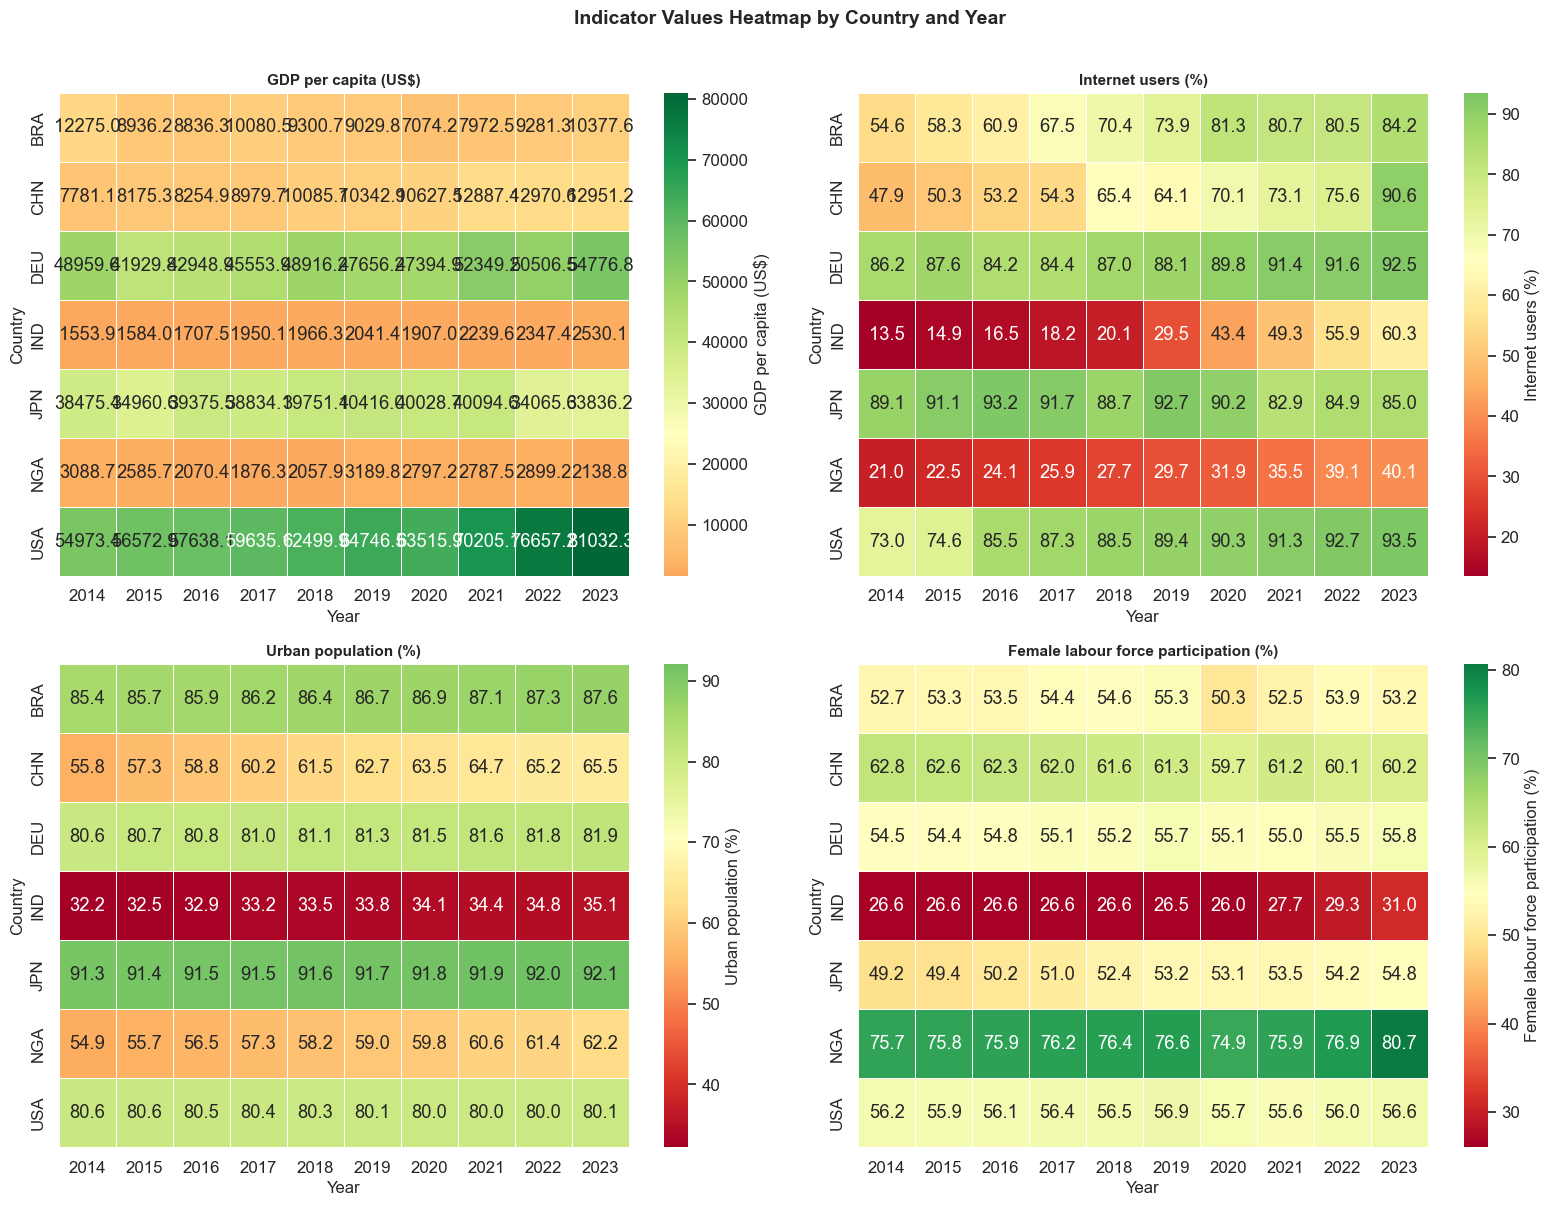

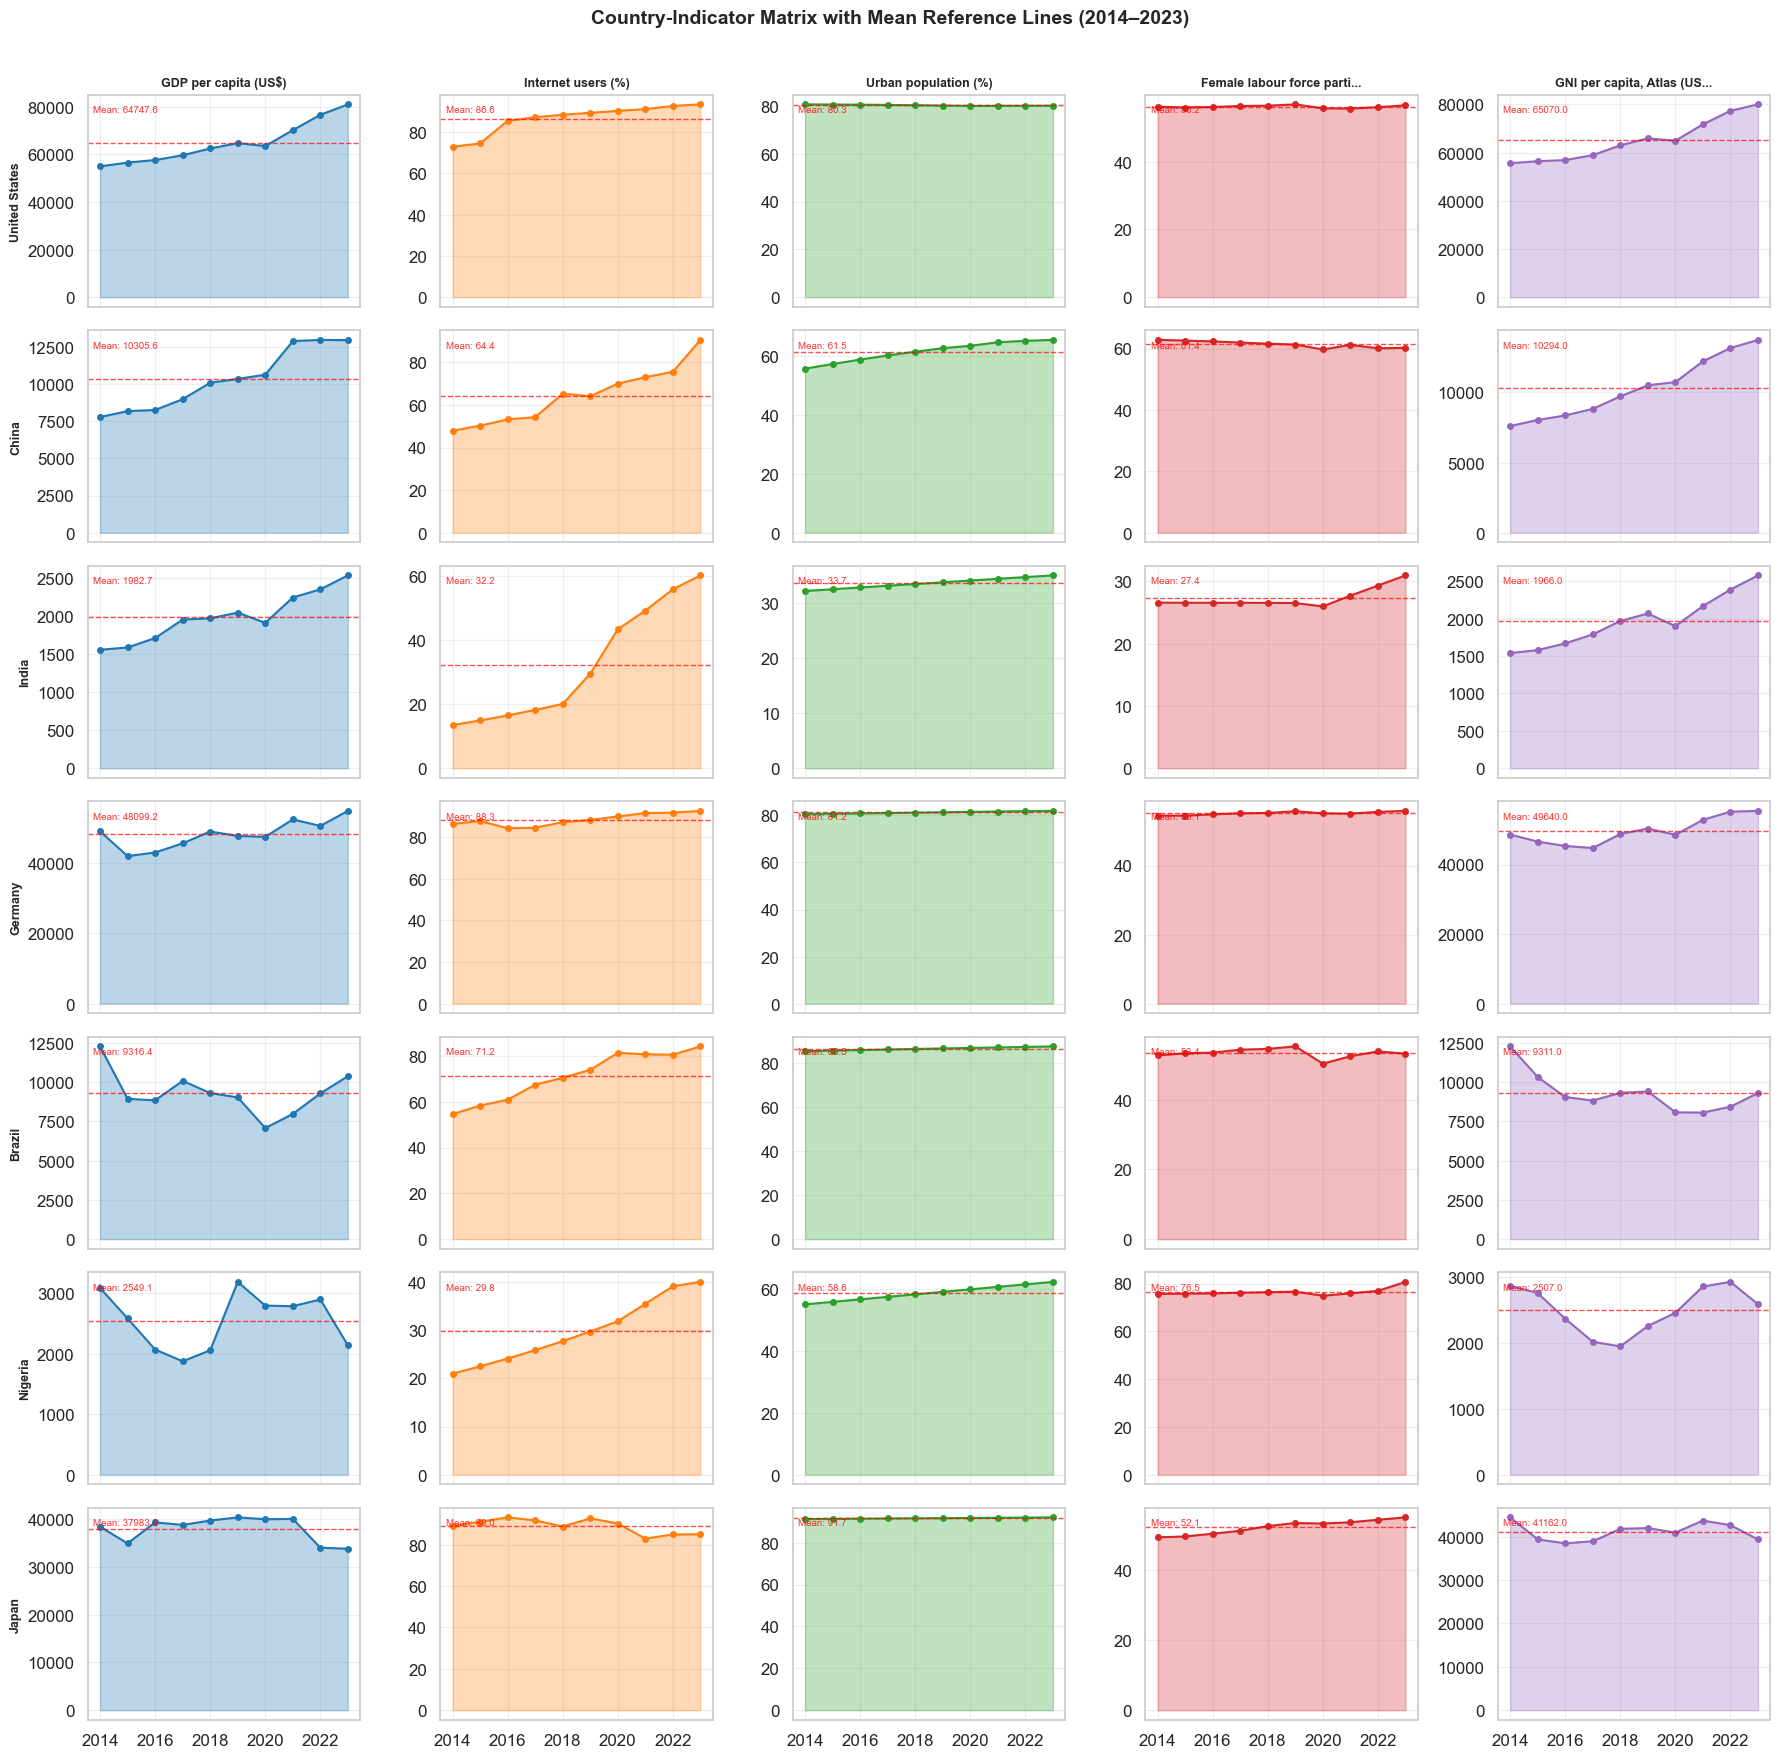

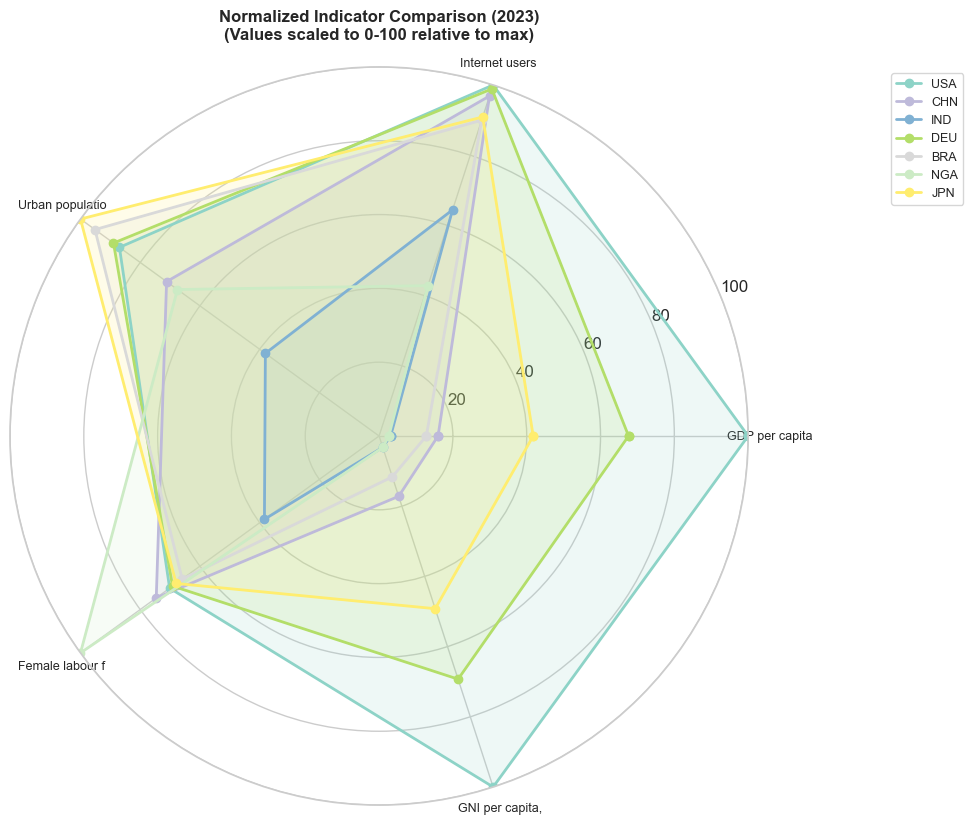


Time-Series Visualisation complete. Displayed 5 professional visualization options:
  1. Faceted Grid by Indicator with value annotations
  2. Country Overview with dual-axis (GDP vs percentages)
  3. Heatmap-style matrix for pattern detection
  4. Small multiples with mean reference lines
  5. Radar chart for latest-year comparison


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. Time-Series Visualisation
# ─────────────────────────────────────────────────────────────────────────────

SAMPLE_COUNTRIES = ["USA", "CHN", "IND", "DEU", "BRA", "NGA", "JPN"]

# Get country name mapping for better labels
country_names = df.groupby("country_iso3")["country_name"].first().to_dict()

# ============================================================================
# Visualization Option 1: Faceted Grid by Indicator
# Each indicator gets its own row, each country gets its own line
# ============================================================================

fig, axes = plt.subplots(
    len(INDICATOR_LABELS), 1,
    figsize=(14, 3.5 * len(INDICATOR_LABELS)),
    sharex=True,
)

colors = sns.color_palette("tab10", len(SAMPLE_COUNTRIES))
country_colors = dict(zip(SAMPLE_COUNTRIES, colors))

for i, (code, label) in enumerate(INDICATOR_LABELS.items()):
    ax = axes[i]
    
    for iso3 in SAMPLE_COUNTRIES:
        ts = time_series_data(df, iso3, code)
        if not ts.empty:
            ax.plot(ts["year"], ts["value"], 
                   marker="o", markersize=5, linewidth=2,
                   label=f"{iso3}", color=country_colors[iso3],
                   alpha=0.8)
            
            # Annotate first and last values
            if len(ts) > 1:
                first_val = ts.iloc[0]
                last_val = ts.iloc[-1]
                ax.annotate(f'{first_val["value"]:.1f}', 
                           xy=(first_val["year"], first_val["value"]),
                           xytext=(-15, -15), textcoords='offset points',
                           fontsize=7, alpha=0.7,
                           color=country_colors[iso3])
                ax.annotate(f'{last_val["value"]:.1f}', 
                           xy=(last_val["year"], last_val["value"]),
                           xytext=(10, 0), textcoords='offset points',
                           fontsize=7, alpha=0.7, fontweight='bold',
                           color=country_colors[iso3])
    
    ax.set_ylabel(label, fontsize=10, fontweight='bold')
    ax.set_title(f"{label}", fontsize=11, loc='left', pad=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2013.5, 2023.5)

axes[0].legend(loc='upper left', fontsize=9, ncol=len(SAMPLE_COUNTRIES), 
               title="Countries", title_fontsize=9)
axes[-1].set_xlabel("Year", fontsize=11)

plt.suptitle("World Bank Indicators Time Series by Country (2014–2023)", 
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# ============================================================================
# Visualization Option 2: Country Overview with Statistics Overlay
# Each country gets a detailed subplot with multiple indicators
# ============================================================================

fig, axes = plt.subplots(
    len(SAMPLE_COUNTRIES), 1,
    figsize=(14, 2.8 * len(SAMPLE_COUNTRIES)),
)

for i, iso3 in enumerate(SAMPLE_COUNTRIES):
    ax = axes[i]
    ax2 = ax.twinx()  # Secondary axis for different scales
    
    country_name = country_names.get(iso3, iso3)
    ts_all = df[df["country_iso3"] == iso3].copy()
    
    # Plot GDP per capita on primary axis (large values)
    gdp_data = ts_all[ts_all["indicator_code"] == "NY.GDP.PCAP.CD"]
    if not gdp_data.empty:
        line1 = ax.plot(gdp_data["year"], gdp_data["value"], 
                       marker="s", markersize=6, linewidth=2.5,
                       color="#2E86AB", label="GDP per capita (US$)", alpha=0.9)
        
        # Add trend annotation
        if len(gdp_data) > 1:
            first_gdp = gdp_data["value"].iloc[0]
            last_gdp = gdp_data["value"].iloc[-1]
            growth = ((last_gdp - first_gdp) / first_gdp) * 100
            ax.annotate(f'GDP Δ: {growth:+.1f}%', 
                       xy=(0.02, 0.95), xycoords='axes fraction',
                       fontsize=8, color="#2E86AB", fontweight='bold',
                       verticalalignment='top')
    
    # Plot Internet users on secondary axis (percentage 0-100)
    net_data = ts_all[ts_all["indicator_code"] == "IT.NET.USER.ZS"]
    if not net_data.empty:
        line2 = ax2.plot(net_data["year"], net_data["value"], 
                        marker="o", markersize=5, linewidth=2,
                        color="#A23B72", label="Internet users (%)", alpha=0.9)
    
    # Plot Urban population on secondary axis
    urb_data = ts_all[ts_all["indicator_code"] == "SP.URB.TOTL.IN.ZS"]
    if not urb_data.empty:
        line3 = ax2.plot(urb_data["year"], urb_data["value"], 
                        marker="^", markersize=5, linewidth=2,
                        color="#F18F01", label="Urban pop (%)", alpha=0.9,
                        linestyle='--')
    
    ax.set_title(f"{country_name} ({iso3})", fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel("GDP per capita (US$)", color="#2E86AB", fontsize=9)
    ax2.set_ylabel("Percentage (%)", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis='y', labelcolor="#2E86AB")
    ax.grid(True, alpha=0.3)
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)

axes[-1].set_xlabel("Year", fontsize=11)
plt.suptitle("Economic & Social Indicators by Country (Dual-Axis View)", 
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# ============================================================================
# Visualization Option 3: Heatmap-style Time Series Matrix
# Shows data density and patterns across countries and years
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (code, label) in enumerate(list(INDICATOR_LABELS.items())[:4]):
    ax = axes[idx]
    
    # Create pivot table for heatmap
    pivot_data = df[df["indicator_code"] == code].pivot_table(
        index="country_iso3",
        columns="year",
        values="value",
        aggfunc="mean"
    )
    
    # Filter to sample countries
    pivot_subset = pivot_data.loc[pivot_data.index.isin(SAMPLE_COUNTRIES)]
    
    # Create heatmap
    sns.heatmap(pivot_subset, annot=True, fmt=".1f", cmap="RdYlGn", 
                center=pivot_subset.mean().mean(), ax=ax,
                linewidths=0.5, cbar_kws={"label": label})
    ax.set_title(f"{label}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("Country")

plt.suptitle("Indicator Values Heatmap by Country and Year", 
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# ============================================================================
# Visualization Option 4: Small Multiples with Summary Statistics
# Each country-indicator combination with mean line and confidence interval
# ============================================================================

fig, axes = plt.subplots(
    len(SAMPLE_COUNTRIES), len(INDICATOR_LABELS),
    figsize=(18, 2.5 * len(SAMPLE_COUNTRIES)),
    sharex=True,
)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for i, iso3 in enumerate(SAMPLE_COUNTRIES):
    country_name = country_names.get(iso3, iso3)
    
    for j, (code, label) in enumerate(INDICATOR_LABELS.items()):
        ax = axes[i, j]
        ts = time_series_data(df, iso3, code)
        
        if not ts.empty:
            # Plot actual values
            ax.fill_between(ts["year"], ts["value"], alpha=0.3, color=colors[j])
            ax.plot(ts["year"], ts["value"], marker="o", markersize=4, 
                   color=colors[j], linewidth=1.5)
            
            # Add mean line
            mean_val = ts["value"].mean()
            ax.axhline(y=mean_val, color='red', linestyle='--', 
                      linewidth=1, alpha=0.7, label=f'Mean: {mean_val:.1f}')
            
            # Add range annotation
            ax.annotate(f'Mean: {mean_val:.1f}', 
                       xy=(0.02, 0.95), xycoords='axes fraction',
                       fontsize=7, color='red', alpha=0.8,
                       verticalalignment='top')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=9, color='gray')
        
        # Labels
        if i == 0:
            ax.set_title(label[:25] + "..." if len(label) > 25 else label, 
                        fontsize=9, fontweight='bold')
        if j == 0:
            ax.set_ylabel(country_name, fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(2014, 2024, 2))

plt.suptitle("Country-Indicator Matrix with Mean Reference Lines (2014–2023)", 
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# ============================================================================
# Visualization Option 5: Comparative Radar Chart (Latest Year Snapshot)
# ============================================================================

from math import pi

latest_year = df["year"].max()
radar_data = []

for iso3 in SAMPLE_COUNTRIES:
    country_row = {"country": iso3}
    country_df = df[(df["country_iso3"] == iso3) & (df["year"] == latest_year)]
    
    for code in INDICATOR_LABELS.keys():
        val = country_df[country_df["indicator_code"] == code]["value"].values
        country_row[code] = val[0] if len(val) > 0 else 0
    radar_data.append(country_row)

radar_df = pd.DataFrame(radar_data)

# Normalize data for radar chart (0-100 scale)
categories = list(INDICATOR_LABELS.keys())
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = plt.cm.Set3(np.linspace(0, 1, len(SAMPLE_COUNTRIES)))

for i, iso3 in enumerate(SAMPLE_COUNTRIES):
    row = radar_df[radar_df["country"] == iso3]
    if not row.empty:
        values = []
        for code in categories:
            val = row[code].iloc[0]
            # Normalize based on max across all countries for this indicator
            max_val = radar_df[code].max() if radar_df[code].max() > 0 else 1
            values.append((val / max_val) * 100)
        values += values[:1]  # Complete the circle
        
        ax.plot(angles, values, 'o-', linewidth=2, label=iso3, color=colors[i])
        ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([INDICATOR_LABELS[c][:15] for c in categories], fontsize=9)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
ax.set_title(f"Normalized Indicator Comparison ({latest_year})\n(Values scaled to 0-100 relative to max)", 
            fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nTime-Series Visualisation complete. Displayed 5 professional visualization options:")
print("  1. Faceted Grid by Indicator with value annotations")
print("  2. Country Overview with dual-axis (GDP vs percentages)")
print("  3. Heatmap-style matrix for pattern detection")
print("  4. Small multiples with mean reference lines")
print("  5. Radar chart for latest-year comparison")

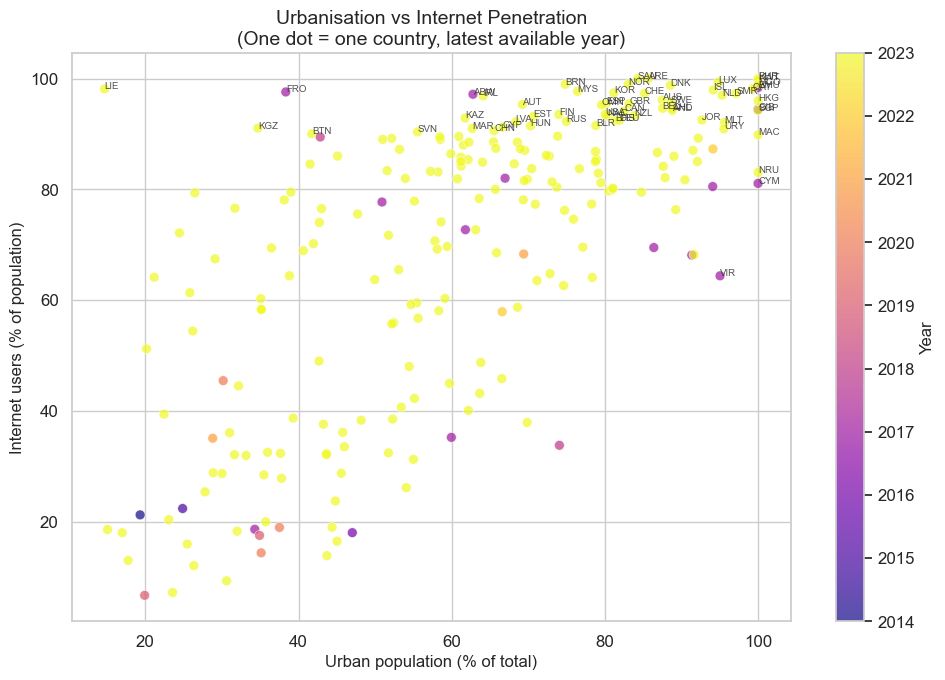

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. Urbanisation vs Internet Penetration (scatter plot)
# ─────────────────────────────────────────────────────────────────────────────

# Merge urbanisation and internet indicators into one wide DataFrame
urban = df[df["indicator_code"] == "SP.URB.TOTL.IN.ZS"]\
         .rename(columns={"value": "urban_pct"})\
         [["country_iso3", "year", "urban_pct"]]

internet = df[df["indicator_code"] == "IT.NET.USER.ZS"]\
            .rename(columns={"value": "internet_pct"})\
            [["country_iso3", "year", "internet_pct"]]

merged = urban.merge(internet, on=["country_iso3", "year"]).dropna()

# Take the most recent year for each country (latest available)
latest = merged.sort_values("year").groupby("country_iso3").last().reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    latest["urban_pct"],
    latest["internet_pct"],
    c=latest["year"],
    cmap="plasma",
    alpha=0.7,
    s=50,
    edgecolors="white",
    linewidths=0.5,
)
ax.set_xlabel("Urban population (% of total)")
ax.set_ylabel("Internet users (% of population)")
ax.set_title("Urbanisation vs Internet Penetration\n(One dot = one country, latest available year)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Year")

# Annotate outliers — countries with very high urbanisation or internet
outliers = latest[(latest["urban_pct"] > 95) | (latest["internet_pct"] > 90)]
for _, row in outliers.iterrows():
    ax.annotate(
        row["country_iso3"],
        (row["urban_pct"], row["internet_pct"]),
        fontsize=7, alpha=0.8,
    )

plt.tight_layout()
plt.show()

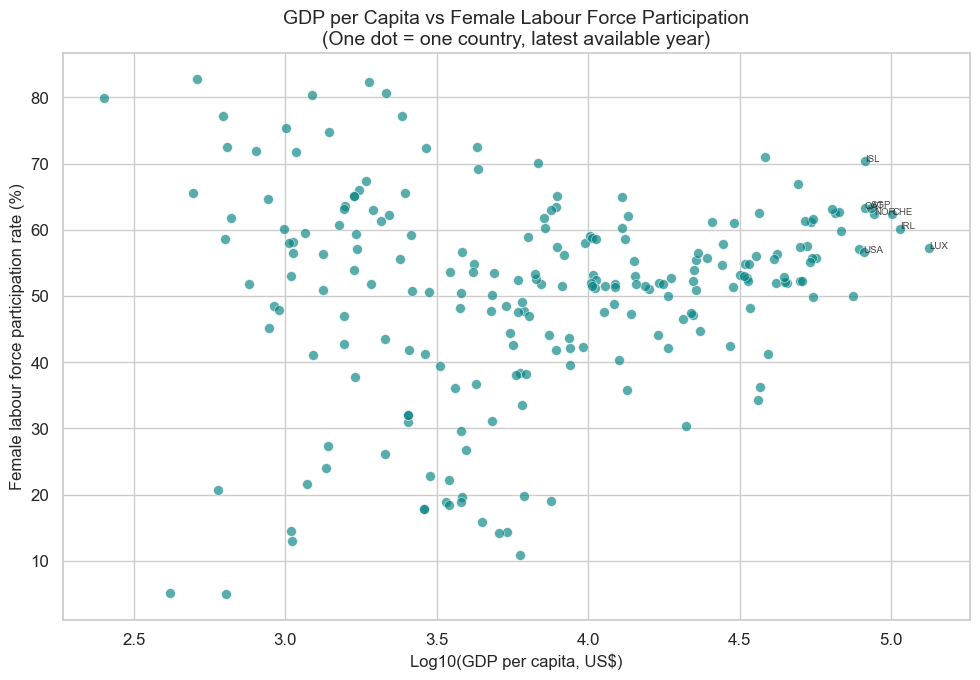

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. GDP vs Female Labour Force Participation (scatter plot)
# ─────────────────────────────────────────────────────────────────────────────

gdp = df[df["indicator_code"] == "NY.GDP.PCAP.CD"]\
       .rename(columns={"value": "gdp_pc"})\
       [["country_iso3", "year", "gdp_pc"]]

flfpr = df[df["indicator_code"] == "SL.TLF.CACT.FE.ZS"]\
         .rename(columns={"value": "flfpr"})\
         [["country_iso3", "year", "flfpr"]]

merged2 = gdp.merge(flfpr, on=["country_iso3", "year"]).dropna()
latest2 = merged2.sort_values("year").groupby("country_iso3").last().reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    np.log10(latest2["gdp_pc"] + 1),   # log-scale for GDP (very skewed)
    latest2["flfpr"],
    alpha=0.65,
    s=50,
    c="teal",
    edgecolors="white",
    linewidths=0.5,
)
ax.set_xlabel("Log10(GDP per capita, US$)")
ax.set_ylabel("Female labour force participation rate (%)")
ax.set_title("GDP per Capita vs Female Labour Force Participation\n"
             "(One dot = one country, latest available year)")

# Annotate notable countries
notable = latest2[(latest2["flfpr"] > 85) | (latest2["gdp_pc"] > 80000)]
for _, row in notable.iterrows():
    ax.annotate(
        row["country_iso3"],
        (np.log10(row["gdp_pc"] + 1), row["flfpr"]),
        fontsize=7, alpha=0.85,
    )

plt.tight_layout()
plt.show()

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# End of EDA Notebook
# ─────────────────────────────────────────────────────────────────────────────

print("EDA notebook complete.")
print(f"Panel: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Countries: {df['country_iso3'].nunique()}  |  "
      f"Years: {df['year'].min()}–{df['year'].max()}  |  "
      f"Indicators: {df['indicator_code'].nunique()}")

EDA notebook complete.
Panel: 11,817 rows × 5 columns
Countries: 255  |  Years: 2014–2023  |  Indicators: 5
